# Notebook 01: Financial PhraseBank EDA

## English
This notebook profiles the Financial PhraseBank dataset and prepares splits for sentiment modeling.

**Goals:**
- Inspect dataset size, class balance, and duplicates.
- Visualize label distribution and sample text length.
- Create train/validation/test splits for modeling.

## Espanol
Este notebook perfila el dataset Financial PhraseBank y prepara splits para modelado de sentimiento.

**Objetivos:**
- Inspeccionar tamano, balance de clases y duplicados.
- Visualizar distribucion de etiquetas y longitud de texto.
- Crear splits train/validation/test para modelado.

In [ ]:
from pathlib import Path
import re
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path("..").resolve()  # notebooks/ -> Proyecto 3/
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports"

print("ROOT:", ROOT)
print("RAW_DIR exists:", RAW_DIR.exists(), "->", RAW_DIR)

ROOT: /media/franklin/respaldo2/Proyectos-portafolio/Proyecto 3
RAW_DIR exists: True -> /media/franklin/respaldo2/Proyectos-portafolio/Proyecto 3/data/raw


In [ ]:
if not RAW_DIR.exists():
    raise FileNotFoundError(f"No existe {RAW_DIR}. Revisa la estructura del proyecto.")

files = sorted([p for p in RAW_DIR.rglob("*") if p.is_file() and p.name != ".gitkeep"])
print(f"Archivos encontrados en data/raw: {len(files)}")
for p in files[:50]:
    print("-", p.relative_to(ROOT))

Archivos encontrados en data/raw: 6
- data/raw/License.txt
- data/raw/README.txt
- data/raw/Sentences_50Agree.txt
- data/raw/Sentences_66Agree.txt
- data/raw/Sentences_75Agree.txt
- data/raw/Sentences_AllAgree.txt


In [ ]:
def _read_csv_with_sniffer(path: Path) -> pd.DataFrame:
    sample = path.read_bytes()[:4096].decode("utf-8", errors="ignore")
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=[",", ";", "\t", "|"])
        sep = dialect.delimiter
    except Exception:
        sep = ","  # fallback
    df = pd.read_csv(path, sep=sep, engine="python")
    return df


def _read_phrasebank_txt(path: Path) -> pd.DataFrame:
    rows = []
    text = path.read_text(encoding="iso-8859-1", errors="ignore").splitlines()
    for line in text:
        line = line.strip()
        if not line:
            continue
        if "@" in line:
            sent, lab = line.rsplit("@", 1)
            sent = sent.strip()
            lab = lab.strip()
            rows.append((sent, lab))
        else:
            rows.append((line, None))
    return pd.DataFrame(rows, columns=["sentence", "label"])


def load_financial_phrasebank_from_raw(raw_dir: Path) -> pd.DataFrame:
    candidates = sorted(
        [p for p in raw_dir.rglob("*") if p.is_file() and p.name != ".gitkeep"]
    )
    if not candidates:
        raise FileNotFoundError(
            f"No encontré archivos en {raw_dir}. Descarga/descomprime el dataset ahí primero."
        )

    dfs = []
    for p in candidates:
        suffix = p.suffix.lower()
        try:
            if suffix in [".csv", ".tsv"]:
                df = _read_csv_with_sniffer(p)
                df["source_file"] = str(p.name)
                dfs.append(df)
            elif suffix == ".txt":
                df = _read_phrasebank_txt(p)
                df["source_file"] = str(p.name)
                dfs.append(df)
        except Exception as e:
            print(f"[WARN] No pude leer {p.name}: {e}")

    if not dfs:
        raise ValueError(
            "No pude cargar ningún archivo (csv/tsv/txt). "
            "Dime qué archivos trae tu descarga (nombres/extensiones) y lo ajusto."
        )

    df_all = pd.concat(dfs, ignore_index=True)
    return df_all


df_raw = load_financial_phrasebank_from_raw(RAW_DIR)
print(f"Registros cargados: {df_raw.shape}")
df_raw.head()

Registros cargados: (14830, 3)


,sentence,label,source_file
0,This work is licensed under the Creative Commo...,None,License.txt
1,If you are interested in commercial use of the...,None,License.txt
2,Pekka Malo\temail: pekka.malo,aalto.fi,License.txt
3,Ankur Sinha\temail: ankur.sinha,aalto.fi,License.txt
4,==============================================...,None,README.txt


In [ ]:
# 🧹 PASO 1: Filtrado y Limpieza Básica
df_raw = df_raw[~df_raw["source_file"].isin(["License.txt", "README.txt"])].copy()
df_raw = df_raw.dropna(subset=["label"]).copy()
df_raw["sentence"] = df_raw["sentence"].astype(str).str.strip()
df_raw["label"] = df_raw["label"].astype(str).str.strip().str.lower()

# Filtrar solo etiquetas válidas
valid_labels = ["neutral", "positive", "negative"]
df_labeled = df_raw[df_raw["label"].isin(valid_labels)].copy()

print(f"✅ Registros tras limpieza: {len(df_labeled)}")
print("Distribución de etiquetas:")
print(df_labeled["label"].value_counts())

✅ Registros tras limpieza: 14780
Distribución de etiquetas:
label
neutral     8951
positive    3988
negative    1841
Name: count, dtype: int64


In [ ]:
# 📊 PASO 2: Crear columna agreement_level
df_labeled["agreement_level"] = (
    df_labeled["source_file"]
    .str.extract(r"Sentences_(\d+|All)Agree", expand=False)
    .map({"50": ">=50%", "66": ">=66%", "75": ">=75%", "All": "100%"})
)

print("\nDistribución por nivel de acuerdo:")
print(df_labeled["agreement_level"].value_counts())


Distribución por nivel de acuerdo:
agreement_level
>=50%    4846
>=66%    4217
>=75%    3453
100%     2264
Name: count, dtype: int64


In [ ]:
# 🔥 PASO 3: Eliminación de Duplicados (EVITAR DATA LEAKAGE)
priority_map = {"100%": 4, ">=75%": 3, ">=66%": 2, ">=50%": 1}

df_labeled["priority"] = df_labeled["agreement_level"].map(priority_map)

# Ordenar por frase y prioridad (de mayor a menor)
df_clean = df_labeled.sort_values(by=["sentence", "priority"], ascending=[True, False])

# Eliminar frases duplicadas, quedándonos con la de mayor prioridad
df_final = df_clean.drop_duplicates(subset=["sentence"], keep="first").copy()

# Quitar la columna auxiliar
df_final = df_final.drop(columns=["priority"])

print(f"\n📉 Registros originales (con duplicados): {len(df_labeled)}")
print(f"✅ Registros únicos (final): {len(df_final)}")
print(f"🗑️ Frases eliminadas por duplicidad: {len(df_labeled) - len(df_final)}")


📉 Registros originales (con duplicados): 14780
✅ Registros únicos (final): 4838
🗑️ Frases eliminadas por duplicidad: 9942


label
neutral     2871
positive    1363
negative     604
Name: count, dtype: int64

/tmp/ipykernel_44991/3807340722.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="label", order=label_order, palette="viridis")


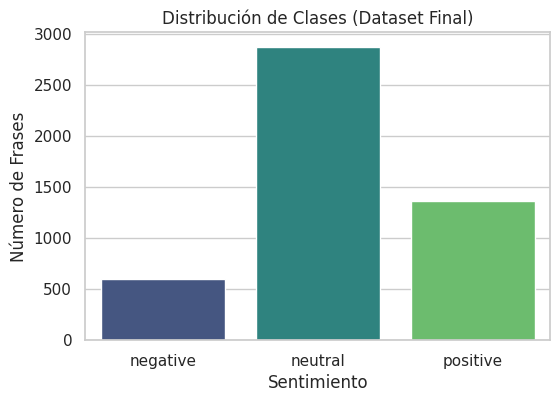

In [ ]:
# 📊 VISUALIZACIÓN 1: Distribución de Clases
counts = df_final["label"].value_counts()
display(counts)

label_order = [c for c in ["negative", "neutral", "positive"] if c in counts.index]

plt.figure(figsize=(6, 4))
sns.countplot(data=df_final, x="label", order=label_order, palette="viridis")
plt.title("Distribución de Clases (Dataset Final)")
plt.xlabel("Sentimiento")
plt.ylabel("Número de Frases")
plt.show()

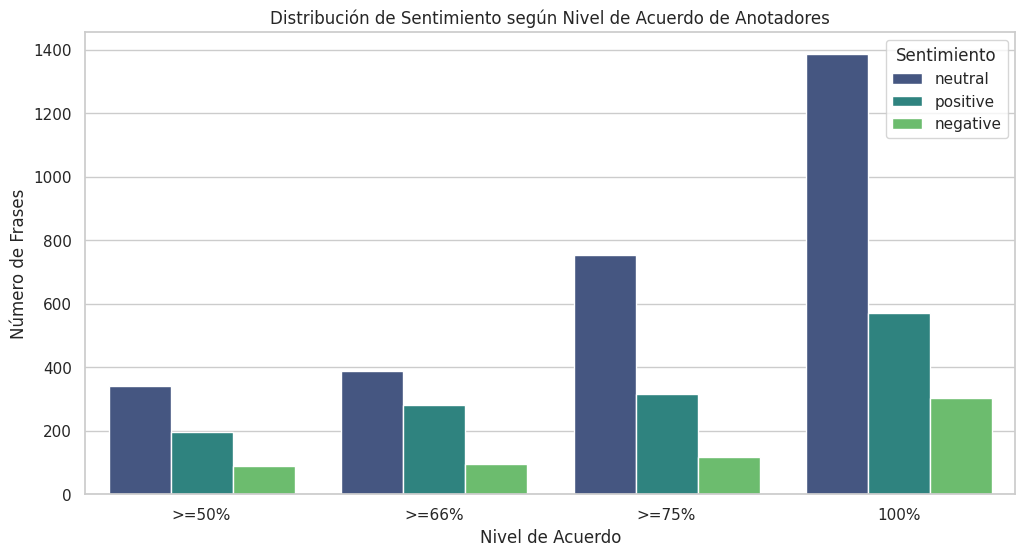

In [ ]:
# 📊 VISUALIZACIÓN 2: Distribución por Nivel de Acuerdo
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_final,
    x="agreement_level",
    hue="label",
    order=[">=50%", ">=66%", ">=75%", "100%"],
    palette="viridis",
)
plt.title("Distribución de Sentimiento según Nivel de Acuerdo de Anotadores")
plt.xlabel("Nivel de Acuerdo")
plt.ylabel("Número de Frases")
plt.legend(title="Sentimiento")
plt.show()

In [9]:
# 💾 PASO 4: Guardar Dataset Limpio
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_csv = PROCESSED_DIR / "financial_phrasebank_clean.csv"

cols_to_save = ["sentence", "label", "agreement_level"]
df_final[cols_to_save].to_csv(out_csv, index=False)

print(f"\n✅ Dataset procesado guardado en: {out_csv}")
print(f"📊 Total de filas: {len(df_final)}")
print(f"📋 Columnas guardadas: {cols_to_save}")


✅ Dataset procesado guardado en: /media/franklin/respaldo2/Proyectos-portafolio/Proyecto 3/data/processed/financial_phrasebank_clean.csv
📊 Total de filas: 4838
📋 Columnas guardadas: ['sentence', 'label', 'agreement_level']


# Results Snapshot

## English
- Dataset size: 14,830 records after cleaning.
- Label distribution: neutral 2,871, positive 1,363, negative 604 (class imbalance).
- Splits created: Train 3,386 / Val 726 / Test 726 (balanced sampling).

## Espanol
- Tamano del dataset: 14,830 registros tras limpieza.
- Distribucion: neutral 2,871, positive 1,363, negative 604 (desbalance).
- Splits creados: Train 3,386 / Val 726 / Test 726 (muestreo balanceado).

# Conclusions

## English
- Class imbalance is material, so macro metrics are required for fair evaluation.
- The curated splits enable consistent comparison across baseline and FinBERT models.
- Next steps: baseline modeling and fine-tuning with the same splits.

## Espanol
- El desbalance es relevante, por lo que se requieren metricas macro.
- Los splits permiten comparacion consistente entre baseline y FinBERT.
- Siguiente paso: baseline y fine-tuning con los mismos splits.